# PMR3404 - Controle I - V2026
# Experiência 3: Projeto de controladores PID utilizando o método do lugar das raízes - Aplicação ao Sistema Ball and Beam

# Identificação

**Aluno1:Matheus Alexandrino Brito**

**NUSP:11261419**

**Aluno2: Augusto Campos**

**NUSP:13684662**

**Turma de Laboratório: 2B**

**Professor: Newton**


## Instruções para edição das células de resposta

1. O manual do jupyter notebook pode ser encontrado em https://jupyter-notebook.readthedocs.io/en/stable/notebook.html

2. As células do jupyter podem conter código ou texto que utiliza uma linguagem de formatação denominada Markdown.
   O manual do markdown é encontrado em https://jupyter-notebook.readthedocs.io/en/latest/examples/Notebook/Working%20With%20Markdown%20Cells.html
   
3. Se clicarmos o botão <RUN> numa célula de texto o jupyter realiza a formatação desse texto.
   Se a célula estiver no modo formatado e clicarmos novamente, entra-se no modo de edição do texto.
   
3. As imagens de figuras podem ser inseridas no markdown através de duas maneiras:
- Fazendo referência a um arquivo de um folder. As figuras utilizadas no texto estão dentro do folder ./Figuras
- Fazendo **copy and paste** de uma imagem para uma região desejada da célula de texto. Dessa forma a imagem da figura fica incorporado no arquivo .ipynb. Recomenda-se esse método para a incorporação de imagens geradas pelo matplotlib. Ao final deve ser verificado se todas as figuras estão incorporadas corretamente. O sistema eventualmente utiliza o mesmo label para se referir a cada imagem e isso pode gerar conflito.
    
4. Os símbolos matemáticos e equações utilizam a sintaxe da linguagem de formatação LaTeX.

5. **Nos scripts o array t que define o vetor de tempo para a simulação e geração dos plots deve ser adaptado para cada caso.**
    
6. **Em algumas situações a estimação da grandeza $\max \theta(t)$ pode gerar erro. Nesse caso não é necessário fazer essa estimativa.**

## Instruções para submissão do relatório

1. Todo relatório deve ser submetido no sistema Moodle de acordo com o deadline estabelecido.
2. Submeta um arquivo compactado contendo o arquivo principal do jupyter notebook (.ipynb) e o folder ./Figuras mesmo que não tenha colocado imagens adicionais.
3. Também no arquivo compactado acrescente uma versão no formato HTML do arquivo jupyter notebook. No menu acesse "File->Save and Export Notebook as ...". O arquivo será utilizado para avaliação do relatório, caso haja dúvidas sobre os resultados o arquivo .ipynb será verificado.
4. **Nos arquivos .ipynb e .html você deve manter as células que contêm as saídas das execuções dos scripts em Python com as últimas respostas obtidas. Seções que não apresentarem indícios que os scripts foram executados não serão consideradas para nota.**

# 1- Roteiro

Nessa terceira aula prática vamos aprofundar a utilização da Linguagem Python para o projeto de sistemas
de controle utilizando o método do lugar das raízes visando atender a requisitos de desempenho.

Os seguintes temas serão abordados:
- Revisitar projeto de um sistema de controle de posição utilizando controlador proporcional e proporcional derivativo,
- Aplicar o controle projetado a partir de uma dinâmica linearizada para um sistema não-linear

# 2- Introdução

O sistema Ball on Beam é composto por uma colocada sobre uma viga, conforme Figura 1, onde ela pode rolar com 1 grau de liberdade ao longo de todo o comprimento da viga. Um braço de alavanca está preso a um dos extremos da viga, e um servo está conectada ao outro. À medida que o servo gira por um ângulo $\theta$, a alavanca altera o ângulo da viga em $\alpha$. Quando o ângulo é alterado a partir da posição horizontal, a gravidade faz com que a bola role ao longo da viga. 


<img src="./Figuras/ball_beam_setup.png" width="40%" height="40%"/>

# 3- Modelagem do Sistema

Assumindo que a bola rola sem escorregar e que o atrito entre a viga e a bola é desprezível, pode-se modelar a dinâmca para o movimento da bola como:

$$
\left(\frac{J}{R^2} + m \right)\ddot{r} + mg\sin\alpha - mr\dot{\alpha}^2 = 0
$$


Como se pode notar, há duas não linearidades na equação dinâmica. Considerando pequenos ângulos $\alpha$, pode-se linearizar essa equação em torno da posição angular de equilíbrio da viga $\alpha = 0$, tendo-se:

$$
\left(\frac{J}{R^2} + m \right)\ddot{r} + mg\alpha = 0
$$

A relação entre o ângulo da viga com o ângulo da motor também pode ser aproximada como uma equação linear da seguinte forma:

$$
\alpha = \frac{d}{L}\theta
$$

Com isso, obtemos a equação dinâmica linearizada:

$$
\left(\frac{J}{R^2} + m \right)\ddot{r} + mg\frac{d}{L}\theta = 0
$$

Com base nessa equação linearizada, podemos projetar um controlador, utilizando o Método do Lugar das Raízes, de modo que a posição da bola possa ser ajustada.

## 3.1- Funções de transferência

Lembrando da experiência anterior (Experiência 2), o primeiro passo para o projeto deste tipo controlador é a determinação do modelo da planta do sistema. Para tanto, pode-se tomar a transformada de Laplace da dinâmica linearizada do sistema, obtendo-se:

$$
\left(\frac{J}{R^2} + m \right)\mathcal{R}(s)s^2 + mg\frac{d}{L}\Theta(s) = 0
$$

Rearranjando os termos desta equação, a função de transferência da planta é dada por:

$$
G(s) = \frac{\mathcal{R}(s)}{\Theta(s)} = \frac{-mgd}{L\left(\frac{J}{R^2} + m \right)}\frac{1}{s^2}
$$

Os parâmetros do sistema estão definidos na Tabela abaixo:

| Parâmetro | Descrição | Valor | 
|:--|:--|:--|
|$m$ | Massa da Bola | $0.11kg$ |
|$R$ | Raio da Bola| $0.015m$ |
|$g$ | Gravidade | $-9.8m/s^2$ |
|$L$ | Comprimento da Viga | $1m$ |
|$d$ | Comprimento da Alavanca| $0.03m$ |
|$J$ | Momento de Inércia da Bola | $9.99e^{-6}kgm^2$ |
|$r$ | Coordenada da bola  | $m$ |
|$\alpha$ | Ângulo da viga  | $rad$ |
|$\theta$ | Ângulo do motor   | $rad$ |
        
Nessa experiência continuamos interessados no projeto de controladores $H(s)$ do tipo PID ou uma de suas variantes, que são listadas abaixo para recordação:

|-|Tipo|
|---|---|
|$$H(s) = K_p$$ | Controlador P |
|$$H(s) = K_p \left( 1 + \frac{1}{T_is} \right)$$ | Controlador PI |
|$$H(s) = K_p \left( 1 + T_d s \right)$$ | Controlador PD |
|$$H(s) = K_p \left( 1 + T_d\frac{s}{\frac{T_d}{N}s+1} \right)$$ | Controlador PD com Filtro |
|$$H(s) = K_p \left( 1 + \frac{1}{T_is}+T_d s \right)$$ | Controlador PID |
|$$H(s) = K_p\left( 1 + \frac{1}{T_is}+T_d\frac{s}{\frac{T_d}{N}s+1} \right)$$ | Controlador PID com Filtro |

# OBSERVAÇÕES:

- Os ítens 4, 5 contêm as especificações de projetos de sistemas de controle e o questionário que você deve responder. Para cada ítem existem dois scripts que devem ser utilizados:

1-) O primeiro script gera um gráfico do lugar das raízes interativo, i.e., você pode clicar com o mouse um ponto do gráfico e o programa imprime o valor de $K_p$ e os pólos correspondentes. A função ZOOM pode ser utilizada para ampliar áreas de interesse. Depois de uma operação de ZOOM o símbolo de zoom deve ser clicado para desabilitar a função.

2-) No segundo script insere-se o valor dos parâmetros do controlador e o script calcula todas as informações de malha aberta e fechada além de gerar o gráfico da resposta transitória para entrada degrau.

- Os scripts se encontram após o final do questionário de cada um dos ítens.

- A função stepinfo() eventualmente pode apresentar erro de execução para o caso da estimação das características da resposta do esforço de controle ($\theta(t)$). Somente nos interessa estimar o valor máximo de $\theta(t)$. Caso ocorra um erro de execução, realize os seguintes passos:
   - comentar a linha referente a função stepinfo();
   - o programa continua a execução do cálculo da resposta a degrau, função step();
   - Estimar o valor máximo de $\theta(t)$ através do gráfico gerado.
   
- Você deve submeter o seu relatório num único arquivo compactado contendo o seu arquivo formato jupyter notebook .ipynb e o diretório contendo todas as figuras do seu relatório.

- Para a geração do gráfico do lugar das raízes com comportamento interativo utiliza-se o comando
  !matplotlib
  Entretando ocorre eventualmente uma falha e o gráfico é gerado inline sem interação. Nesse caso você deve resetar o kernel e o espaço das variáveis. Siga o caminho no Menu: (Kernel) - (Restart & Clear Output)

# 4- Controlador P para o sistema de controle de posição

Vamos projetar um controlador para a posição da bola que que atenda aos seguintes requisitos:

- Erro estático nulo para uma entrada degrau unitário,
- Tempo de assentamento $t_s < 3s$,
- Máximo sobresinal $M_p < 10\%$.

Inicialmente, considere um controlador proporcional $H(s)=K_p$, para tanto:

a-) Esboce o Lugar Geométrico dos pólos no plano complexo $s$ que satisfazem
		      os requisitos do regime transitório.
              
**[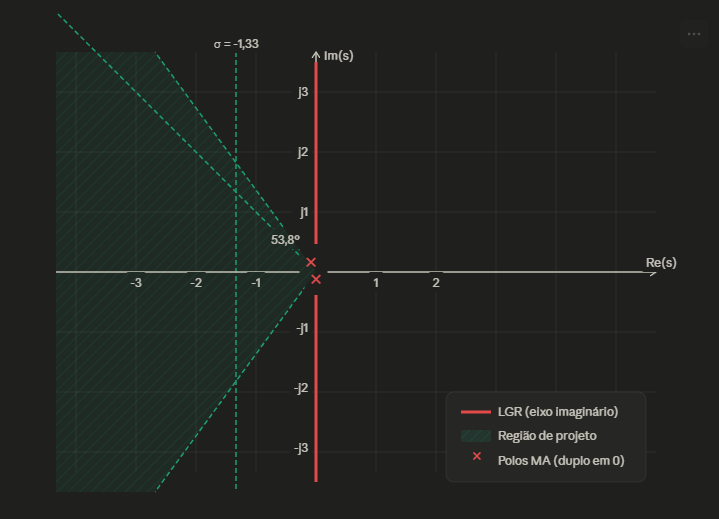]**
	          


b-) Identifique os pólos da malha aberta $G(s)H(s)$.

**[substituir os valores de x na tabela]**
 
| pólo 1 | pólo 2 |
| :- | :- |
|   0+0j   |   0+0j   |
 
c-) Escreva a função de transferência do sistema em malha aberta com valores numéricos:

**[substituir os valores de x]**
  
   $$
   G(s)H(s)=\frac{0.21}{s^2}
   $$	

d-) Utilizando o método do lugar das raízes projete, se possível, o valor do ganho $K_p$ tal que o sistema de controle em malha fechada atenda aos requisitos. Utilize os scripts abaixo. Um controlador proporcional é capaz de satisfazer os requisitos?

 
K_p = 1  	
 
 **[Os polos de malha fechada ficam sempre sobre o eixo imaginário, independentemente do valor de Kp. Isso significa que o sistema fica na fronteira da estabilidade, ou seja, oscila permanentemente tornando assim o controlador proporcional incapaz de sastifazer os requisitos.]**   		  
 
e-) Gráfico do Lugar das Raízes evidenciando os pólos escolhidos:

**[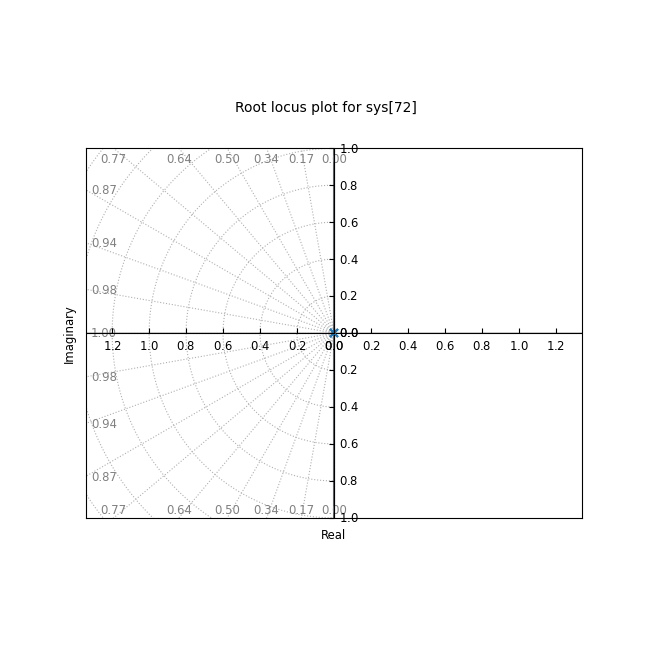]**
		
f-) Identifique os pólos de malha fechada para o valor de $K_p$ escolhido:

**[substituir os valores de x na tabela]**
 
| pólo 1 | pólo 2 |
| :- | :- |
|   0 - 0.45j   |   0 + 0.45j   |

g-) Escreva a função de transferência em malha fechada do sistema com valores numéricos:

**[substituir os valores de x]**

   $$
   \frac{GH(s)}{1+GH(s)}= \frac{0.21kp}{s^2 + 0.21kp}
   $$	  	

h-) Gráfico da resposta transitória para uma entrada do tipo degrau unitário.

**[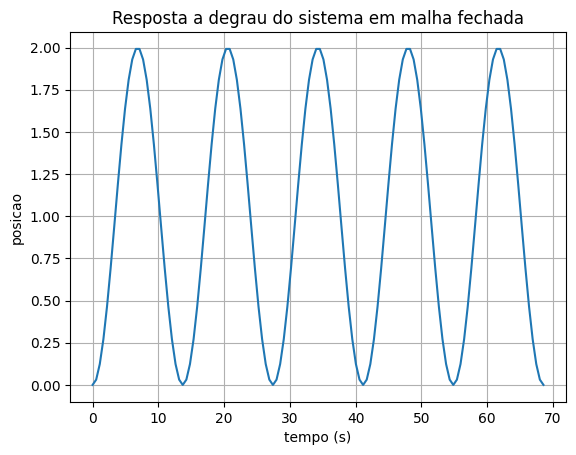]**

i-) Anote na tabela abaixo os valores obtidos para o tempo de subida $t_r$, tempo de acomodação $t_s$, Máximo sobresinal $M_p$ da variável $r(t)$ (saída do sistema) e $\max\theta(t)$ (Valor máximo da saída do controlador $\theta(t)$):

**[substituir os valores de x na tabela]**

| $$t_r$$ | $$t_s$$ | $$M_p$$ | $$\max \theta(t)$$ |
|:-|:-|:-|:-|
| 3.41| ∞ | 100% | 2 |


j-) Analise a estabilidade do sistema de controle de malha fechada
	          em função do valor $K_p$.
              
**[O controlador P nunca estabiliza para qualquer valor de kp, onde Kp>0, oscilação permanente, ja para Kp<=0 o sistema fica instavel]**              


# Script para o ítem 4: Controlador P - Controle de posição - Lugar das Raízes

C:\Users\nigtt\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\control\rlocus.py:202: FutureWarning: root_locus() return value of roots, gains is deprecated; use root_locus_map()
  warnings.warn(
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


Using matplotlib backend: inline
Polos da planta G(s) =  [0.+0.j 0.+0.j]
Zeros da planta G(s) =  []


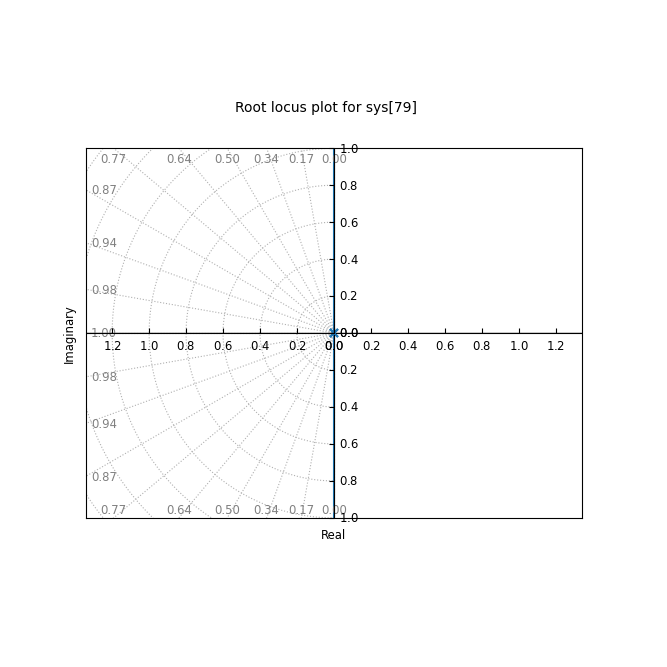

In [9]:
import numpy as np
import control as co_general
import matplotlib.pyplot as plt
import control.matlab as co
# Escolher essa opcao para o plot interativo do LR em janela fora do notebook
%matplotlib
# Opcao para plot interativo dentro do notebook (mais dificil controlar o zoom)
#%matplotlib notebook 
# Lugar das raizes sem interacao
#%matplotlib inline         

# Fecha todas as janelas
plt.close('all')
#
# Definicao dos valores dos parametros do sistema
#
# Parametros da funcao de transferencia G(s)
m = 0.111
R = 0.015
g = -9.8
L = 1.0
d = 0.03
J = 9.99e-6
#
# Funcao de transferencia da posicao do sistema
s = co.tf('s')
G = -m*g*d/L/(J/R**2+m)/s**2
# Polos e zeros de Gtheta(s)
print('Polos da planta G(s) = ', co.pole(G))
print('Zeros da planta G(s) = ', co.zero(G))
# Definicao do controlador P
H = 1 # Kp inicialmente vale 1 pois sera selecionado pelo LR

# Funcao de Transferencia de Malha Aberta
GH=G*H
[rlist,klist]=co.rlocus(GH,grid=True)

# Script para o ítem 4: Controlador P - Controle de posição - Resumo do Projeto

Escolhido o valor de $K_p$, através do lugar das Raízes, prossiga executando o script a seguir que calcula todas as grandezas necessárias que caracterizam o projeto 

-------------
FT da planta G(s) = 
<TransferFunction>: sys[37]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

  0.21
  ----
  s^2
-------------
FT DE MALHA ABERTA GH(s)=G(s)*H(s) = 
<TransferFunction>: sys[39]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

  0.21
  ----
  s^2
-------------
POLOS E ZEROS DE MALHA ABERTA
Polos de GH(s) =  [0.+0.j 0.+0.j]
Zeros de GH(s) =  []
-------------
FT DE MALHA FECHADA GH(s)/(1+GH(s))
<TransferFunction>: sys[41]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

     0.21
  ----------
  s^2 + 0.21
-------------
POLOS E ZEROS DE MALHA FECHADA
Polos da planta cloop(s) =  GH(s)/(1+GH(s)) =  [-0.+0.45825757j  0.-0.45825757j]
Zeros da planta cloop(s) =  GH(s)/(1+GH(s)) =  []
-------------
COEF. DE AMORTECIMENTO E FREQ. NATURAL
_____Polos____________zeta_______omegan
    Eigenvalue (pole)       Damping     Frequency
        -0   +0.4583j             0        0.4583
         0   -0.4583j            -0        0.4583
-------------
CARACTERISTICAS DA RESPOSTA TRANSITORIA

C:\Users\nigtt\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\control\timeresp.py:1712: RuntimeWarning: divide by zero encountered in divide
  np.abs(yout/InfValue - 1) >= SettlingTimeThreshold)[0]


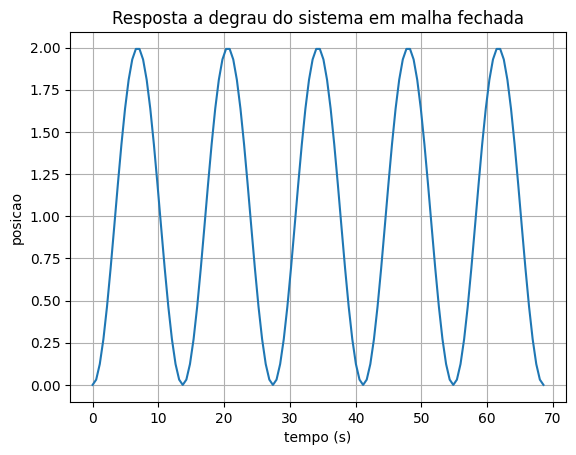

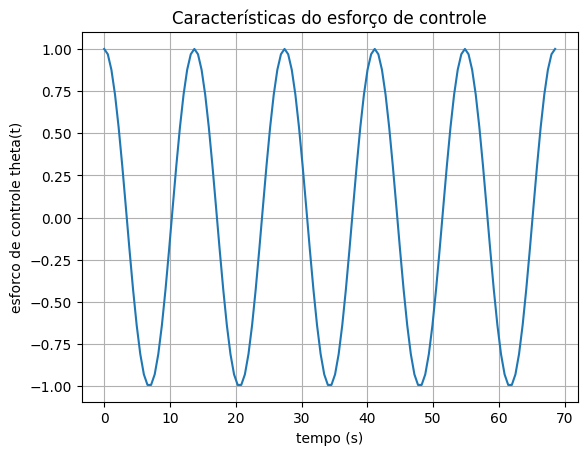

In [4]:
# Python packages
import numpy as np
import control as co_general
import control.matlab as co
import matplotlib.pyplot as plt
%matplotlib inline
#
# Controle de Posicao Angular com controlador PID
#
# Definicao dos valores dos parametros do sistema
# Parametros da funcao de transferencia G(s)
m = 0.111
R = 0.015
g = -9.8
L = 1.0
d = 0.03
J = 9.99e-6
# Funcao de transferencia da posicao do sistema G(s)
# Definicao de s como funcao de transferencia
s = co.tf('s')
G = -m*g*d/L/(J/R**2+m)/s**2
print('-------------')
print('FT da planta G(s) = ')
print(G)
# Setar o ganho obtido pelo LR
Kp = 1
# Controlador Proporcional
H = Kp
# Malha aberta
GH=G*H
print('-------------')
print('FT DE MALHA ABERTA GH(s)=G(s)*H(s) = ')
print(GH)
print('-------------')
print('POLOS E ZEROS DE MALHA ABERTA')
print('Polos de GH(s) = ', co.pole(GH))
print('Zeros de GH(s) = ', co.zero(GH))
#co.pzmap(GHp,grid=True,title='PZMAP malha aberta')
# Funcao de transferencia em malha fechada
cloop = co.feedback(GH,1)
print('-------------')
print('FT DE MALHA FECHADA GH(s)/(1+GH(s))')
print(cloop)
print('-------------')
print('POLOS E ZEROS DE MALHA FECHADA')
print('Polos da planta cloop(s) =  GH(s)/(1+GH(s)) = ', co.pole(cloop))
print('Zeros da planta cloop(s) =  GH(s)/(1+GH(s)) = ', co.zero(cloop))
#co.pzmap(cloop,grid=True,title='PZMAP malha fechada')
print('-------------')
print('COEF. DE AMORTECIMENTO E FREQ. NATURAL')
print('_____Polos____________zeta_______omegan')
co.damp(cloop)
# Calcula as caracteristicas da resposta transitoria
#  stepinfo(sys, T=None, SettlingTimeThreshold=0.02, RiseTimeLimits=(0.1,0.9))
#  S: a dictionary containing:
#        RiseTime: Time from 10% to 90% of the steady-state value.
#        SettlingTime: Time to enter inside a default error of 2%
#        SettlingMin: Minimum value after RiseTime
#        SettlingMax: Maximum value after RiseTime
#        Overshoot: Percentage of the Peak relative to steady value
#        Undershoot: Percentage of undershoot
#        Peak: Absolute peak value
#        PeakTime: time of the Peak
#        SteadyStateValue: Steady-state value
S=co.stepinfo(cloop)
print('-------------')
print('CARACTERISTICAS DA RESPOSTA TRANSITORIA DO SISTEMA')
print('tempo de subida tr = ','%.2f' % S['RiseTime'],'seg')
print('tempo de acomodacao ts = ','%.2f' % S['SettlingTime'],'seg')
print('maximo sobresinal Mp = ',S['Overshoot'])
print('valor de pico rmax = ','%.2f' % S['Peak'])
print('instante de pico tp = ','%.2f' % S['PeakTime'],'seg')
print('valor de regime estacionario rss = ','%.2f' % S['SteadyStateValue'])
# Grafico da resposta a degrau unitario
plt.figure(3)
r, t = co.step(cloop)
plt.plot(t,r)
plt.title('Resposta a degrau do sistema em malha fechada')
plt.xlabel('tempo (s)')
plt.ylabel('posicao')
plt.grid()
#
# Esforco de controle
#
# Funcao de transferencia para calculo do esforco de controle u(t)
# o sinal u(t) pode ser calculado definindo-se
# um sistema de controle em malha fechada onde H(s)
# esta na malha direta e G(s) na malha de realimentacao
#
# R(s)  E(s)|------|        U(s)
#---->(+)---| H(s) |------------>
#    _ ^    |------|    |
#      |                |
#      |    |------|    |
#      |----| G(s) |<----
#           |------|
# 
esforco=co.feedback(H,G)
print('-------------')
print('FT DO ESFORCO DE CONTROLE H(s)/(1+H(s)G(s))')
print(esforco)
# Caracteristicas da resposta transitória
SE=co.stepinfo(esforco)
# Valor de pico
print('-------------')
print('CARACTERISTICAS DO ESFORCO DE CONTROLE')
print('valor de pico theta_max = ','%.2f' % SE['Peak'])
plt.figure(4)
theta, te = co.step(esforco)
plt.plot(te, theta)
plt.title('Características do esforço de controle')
plt.xlabel('tempo (s)')
plt.ylabel('esforco de controle theta(t)')
plt.grid()
plt.show()

# 5- Controlador PD para o sistema de controle de posição

O controlador PD pode ser escrito da seguinte forma:
$$
H_1(s) = K_p\left(1+T_d\frac{s}{\frac{T_d}{N}s+1}\right),
$$

O filtro de 1a. ordem que é definido como:
$$
\frac{1}{\frac{T_d}{N}s+1},
$$
é necessário para garantir que a parte derivativa seja um sistema causal (grau do polinômio do denominador
igual ou maior que o grau do polinômio do numerador), o que garante a estabilidade numérica da simulação.
Além disso, a componente derivativa gera valores de saída extremamente elevados para entradas rápidas, por exemplo, do tipo degrau (Para uma entrada degrau a derivada é infinita) ou ruídos de alta frequência.
Quanto menor o valor de $N$ menor a frequência de corte do filtro.

Agora, vamos retomar o projeto do controlador para a posição da bola que que atenda aos mesmos requisitos de antes:

- Erro estático nulo para uma entrada degrau unitário,
- Tempo de assentamento $t_s < 3s$,
- Máximo sobresinal $M_p < 10\%$.

Mas dessa vez, utilizando um controlador do tipo PD.
 
Os parâmetros $T_d$ e $N$ devem ser escolhidos a priori. Vamos utilizar, por exemplo, os seguintes valores: $T_d = 1$ e $N = 100$

Utilizando o script realize um projeto de controlador PD para o sistema de controle de posição.

a-) Identifique os pólos e zeros da malha aberta $GH(s)$:
 
| pólo 1 | pólo 2 | pólo 3| zero |
|:-|:-|:-|:-|
| -100.+0.j | 0.+0.j | 0.+0.j | -0.99009901+0.j | 				  		  

b-) Escreva a função de transferência do sistema em malha aberta com valores numéricos:
	 
$$
GH(s) = \frac{699.9s+693}{s^3+100s^2}
$$


c-) Utilizando o método do lugar das raízes projete o valor do ganho $K_p$ tal que o sistema de controle em malha fechada atenda aos requisitos.
 
 $K_p$=33  						  		  
 
d-) Identifique os pólos e zeros da malha fechada:


| pólo 1 | pólo 2 | pólo 3| zero |
|:-|:-|:-|:-|
| -92.51541654+0.j | -6.294566  +0.j | -1.19001746+0.j | -0.99009901+0.j | 	 
 
e-) Escreva a função de transferência do sistema em malha fechada com valores numéricos:

$$
\frac{GH(s)}{1+GH(s)}= \frac{699.9s+693}{s^3+100s^2+699.9s+693}
$$ 

f-) Esboce abaixo a resposta transitória para uma entrada do tipo degrau unitário:

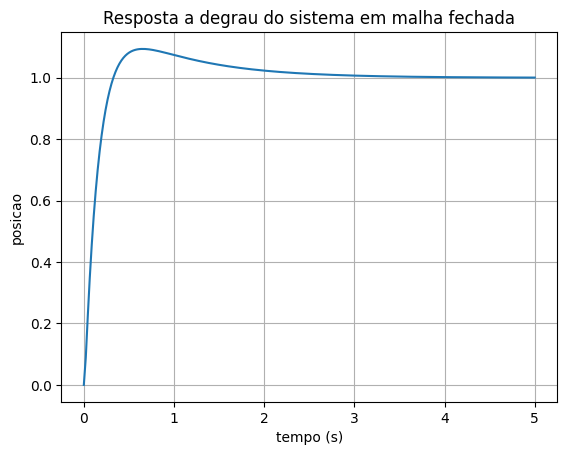

g-) Anote na tabela abaixo os valores obtidos para o tempo de subida $t_r$, tempo de acomodação
$t_s$, Máximo sobresinal $M_p$ da variável $r(t)$ e $\max \theta(t)$ (Valor máximo da saída do controlador
$\theta(t)$) (OBS: $\theta(t)$ não pode ser calculado para $N=\text{Inf}$)

|$$t_r(s)$$|$$t_s(s)$$|$$M_p(%)$$|$$\max \theta(t)$$|
|:-|:-|:-|:-|
|0.22|2.15|9.39|3333|    	  		      		  


# Script para o ítem 5: Controlador PD - Controle de posição - LR

C:\Users\gugaa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\control\rlocus.py:202: FutureWarning: root_locus() return value of roots, gains is deprecated; use root_locus_map()
  warnings.warn(
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


Using matplotlib backend: module://matplotlib_inline.backend_inline


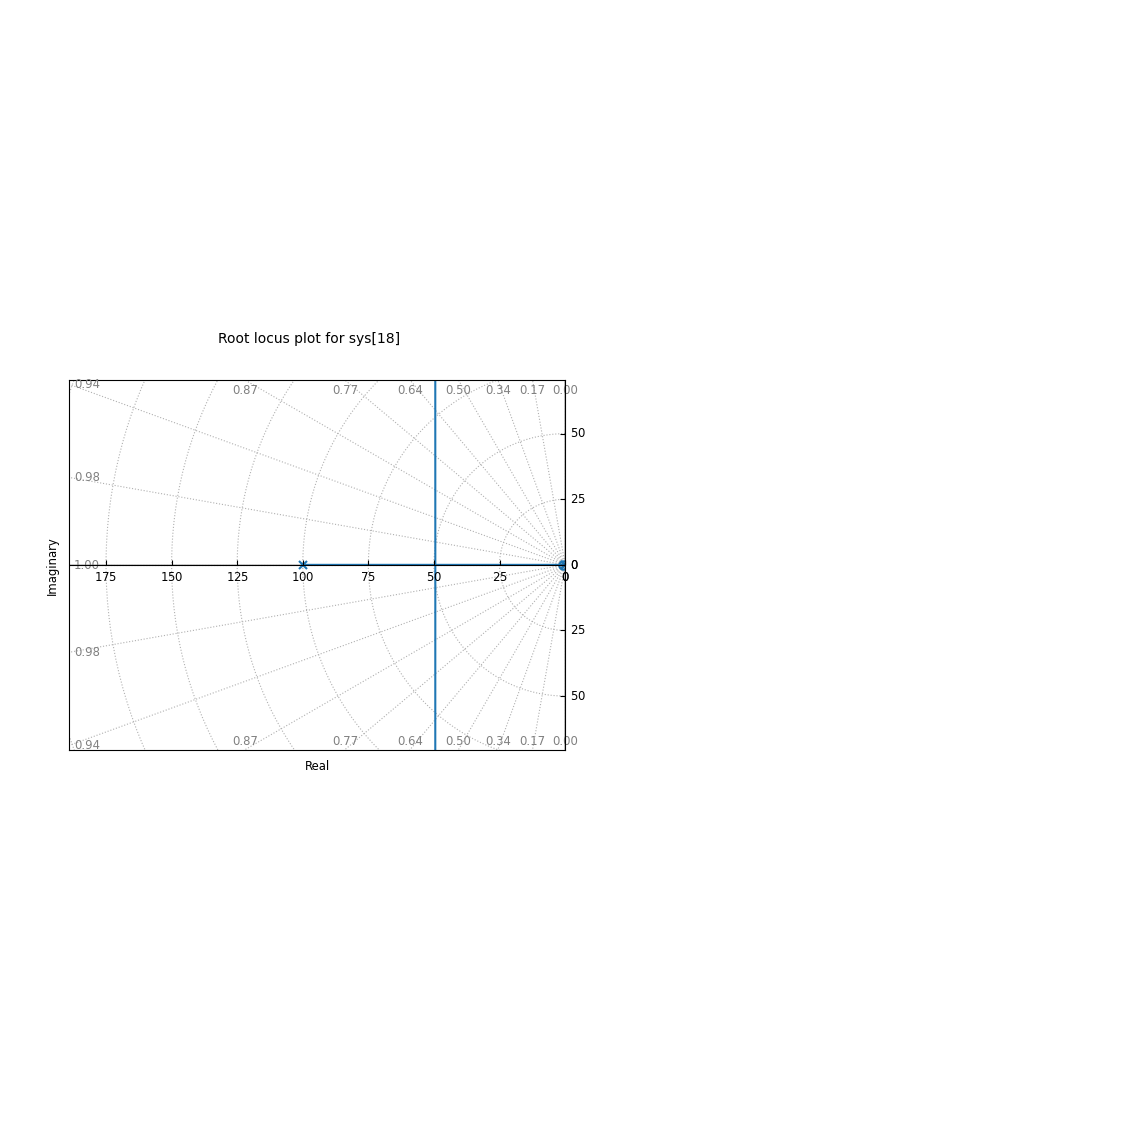

In [3]:
import numpy as np
import control as co_general
import matplotlib.pyplot as plt
import control.matlab as co
# Escolher essa opcao para o plot interativo do LR em janela fora do notebook
%matplotlib
# Opcao para plot interativo dentro do notebook (mais dificil controlar o zoom)
#%matplotlib notebook 
# Lugar das raizes sem interacao
#%matplotlib inline         

# Fecha todas as janelas
plt.close('all')
#
# Testes com controle PID
#
# Definicao dos valores dos parametros do sistema
#
# Parametros da funcao de transferencia G(s)
m = 0.111
R = 0.015
g = -9.8
L = 1.0
d = 0.03
J = 9.99e-6
# Funcao de transferencia da posicao do sistema G(s)
# Definicao de s como funcao de transferencia
s = co.tf('s')
G = -m*g*d/L/(J/R**2+m)/s**2

# Definicao do controlador PD com Filtro
# Kp inicialmente vale 1 pois era selecionado pelo LR
# Controlador PD com filtro
Td = 1
N =  100
H = 1*(1+Td*s/(Td*s/N+1))
# Funcao de Transferencia de Malha Aberta
GH = G*H
[rlist,klist]=co.rlocus(GH,grid=True)

# Script para o ítem 5: Controlador PD- Controle de posição - Resumo do Projeto

-------------
FT da planta G(s) = 
<TransferFunction>: sys[143]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

  0.21
  ----
  s^2
-------------
FT DE MALHA ABERTA GH(s)=G(s)*H(s) = 
<TransferFunction>: sys[157]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

  699.9 s + 693
  -------------
  s^3 + 100 s^2
-------------
POLOS E ZEROS DE MALHA ABERTA
Polos de GH(s) =  [-100.+0.j    0.+0.j    0.+0.j]
Zeros de GH(s) =  [-0.99009901+0.j]
-------------
FT DE MALHA FECHADA GH(s)/(1+GH(s))
<TransferFunction>: sys[159]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

          699.9 s + 693
  -----------------------------
  s^3 + 100 s^2 + 699.9 s + 693
-------------
POLOS E ZEROS DE MALHA FECHADA
Polos da planta cloop(s) =  GH(s)/(1+GH(s)) =  [-92.51541654+0.j  -6.294566  +0.j  -1.19001746+0.j]
Zeros da planta cloop(s) =  GH(s)/(1+GH(s)) =  [-0.99009901+0.j]
-------------
COEF. DE AMORTECIMENTO E FREQ. NATURAL
_____Polos____________zeta_______omegan
    Eigenvalue (pole)       Damping     Frequency
     

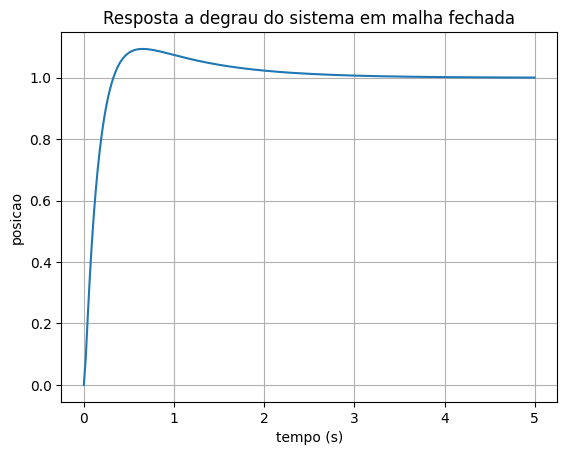

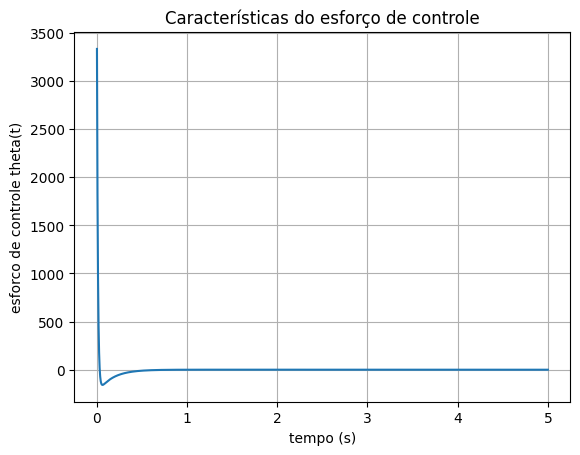

In [8]:
# Python packages
import numpy as np
import control as co_general
import control.matlab as co
import matplotlib.pyplot as plt
%matplotlib inline
#
# Controle de Posicao Angular com controlador PID
#
# Definicao dos valores dos parametros do sistema

# Parametros da funcao de transferencia G(s)
m = 0.111
R = 0.015
g = -9.8
L = 1.0
d = 0.03
J = 9.99e-6
# Funcao de transferencia da posicao do sistema G(s)
# Definicao de s como funcao de transferencia
s = co.tf('s')
G = -m*g*d/L/(J/R**2+m)/s**2
print('-------------')
print('FT da planta G(s) = ')
print(G)
# Setar o ganho obtido pelo LR
Kp = 33
Td = 1
N = 100
# Controlador PD com filtro
H = Kp*(1+Td*s/(Td*s/N+1))

# Malha aberta
GH=G*H
print('-------------')
print('FT DE MALHA ABERTA GH(s)=G(s)*H(s) = ')
print(GH)
print('-------------')
print('POLOS E ZEROS DE MALHA ABERTA')
print('Polos de GH(s) = ', co.pole(GH))
print('Zeros de GH(s) = ', co.zero(GH))
# Funcao de transferencia em malha fechada
cloop = co.feedback(GH,1)
print('-------------')
print('FT DE MALHA FECHADA GH(s)/(1+GH(s))')
print(cloop)
print('-------------')
print('POLOS E ZEROS DE MALHA FECHADA')
print('Polos da planta cloop(s) =  GH(s)/(1+GH(s)) = ', co.pole(cloop))
print('Zeros da planta cloop(s) =  GH(s)/(1+GH(s)) = ', co.zero(cloop))
print('-------------')
print('COEF. DE AMORTECIMENTO E FREQ. NATURAL')
print('_____Polos____________zeta_______omegan')
co.damp(cloop)
# Calcula as caracteristicas da resposta transitoria
#  stepinfo(sys, T=None, SettlingTimeThreshold=0.02, RiseTimeLimits=(0.1,0.9))
#  S: a dictionary containing:
#        RiseTime: Time from 10% to 90% of the steady-state value.
#        SettlingTime: Time to enter inside a default error of 2%
#        SettlingMin: Minimum value after RiseTime
#        SettlingMax: Maximum value after RiseTime
#        Overshoot: Percentage of the Peak relative to steady value
#        Undershoot: Percentage of undershoot
#        Peak: Absolute peak value
#        PeakTime: time of the Peak
#        SteadyStateValue: Steady-state value
S=co.stepinfo(cloop)
print('-------------')
print('CARACTERISTICAS DA RESPOSTA TRANSITORIA DO SISTEMA')
print('tempo de subida tr = ','%.2f' % S['RiseTime'],'seg')
print('tempo de acomodacao ts = ','%.2f' % S['SettlingTime'],'seg')
print('maximo sobresinal Mp = ',S['Overshoot'])
print('valor de pico rmax = ','%.2f' % S['Peak'])
print('instante de pico tp = ','%.2f' % S['PeakTime'],'seg')
print('valor de regime estacionario rss = ','%.2f' % S['SteadyStateValue'])
# Grafico da resposta a degrau unitario
plt.figure(3)
r, t = co.step(cloop, T=5)
plt.plot(t,r)
plt.title('Resposta a degrau do sistema em malha fechada')
plt.xlabel('tempo (s)')
plt.ylabel('posicao')
plt.grid()
#
# Esforco de controle
#
# Funcao de transferencia para calculo do esforco de controle u(t)
# o sinal u(t) pode ser calculado definindo-se
# um sistema de controle em malha fechada onde H(s)
# esta na malha direta e G(s) na malha de realimentacao
#
# R(s)  E(s)|------|        U(s)
#---->(+)---| H(s) |------------>
#    _ ^    |------|    |
#      |                |
#      |    |------|    |
#      |----| G(s) |<----
#           |------|
# 
esforco=co.feedback(H,G)
print('-------------')
print('FT DO ESFORCO DE CONTROLE H(s)/(1+H(s)G(s))')
print(esforco)
# Caracteristicas da resposta transitória
SE=co.stepinfo(esforco)
# Valor de pico
print('-------------')
print('CARACTERISTICAS DO ESFORCO DE CONTROLE')
print('valor de pico max_theta = ','%.2f' % SE['Peak'])
# Grafico da resposta a degrau unitario
plt.figure(4)
theta, te = co.step(esforco, T=5)
plt.plot(te, theta)
plt.title('Características do esforço de controle')
plt.xlabel('tempo (s)')
plt.ylabel('esforco de controle theta(t)')
plt.grid()
plt.show()

# 6- Controlador PD para o ajuste de posição: Aplicação ao sistema não-linearizado

Até este momento, todo o projeto do controlador e verificação de desempenho foi realizado considerando a planta linearizada, conforme visto na Seção 3. Contudo, vimos também que um modelo mais fiel ao que seria o sistema real é expresso por uma equação dinâmica não-linear. Então os controladores projetados utilizandos Técnicas de Controle Linear seriam capazes de também obter o comportamento desejado no sistema não-linear? E se sim, até que "distância" das condições de linearização?

Para verificar isso, lembremos a equação dinâmica completa:

$$
\left(\frac{J}{R^2} + m \right)\ddot{r} + mg\sin\alpha - mr\dot{\alpha}^2 = 0
$$

Como já haviamos mencionado, há duas não-linearidades: $\sin\alpha$ e $r\dot{\alpha}^2$, vamos então analisar o comportamento do sistema não-linear incorporando essas não-linearidades de forma gradual:

## 6.1- Controlador PD para o ajuste de posição: Aplicação ao sistema com não linearidade $\sin\alpha$

Nesse caso, o sistema se reduz a:

$$
\left(\frac{J}{R^2} + m \right)\ddot{r} + mg\sin\alpha = 0
$$

Utilizando os mesmo parâmetros do controle PD projetado anteriormente, vamos verificar o comportamento do sistema.

a-) Para um set-point de $0.25m$ (em relação à ponta esquerda da viga), o sistema com o controlador PD projetado é estável? Esboce abaixo a resposta transitória para uma entrada do tipo degrau unitário:

**Sim, o sistema com o controlador PD projetado se mostrou estável, como visto no gráfico abaixo.**   

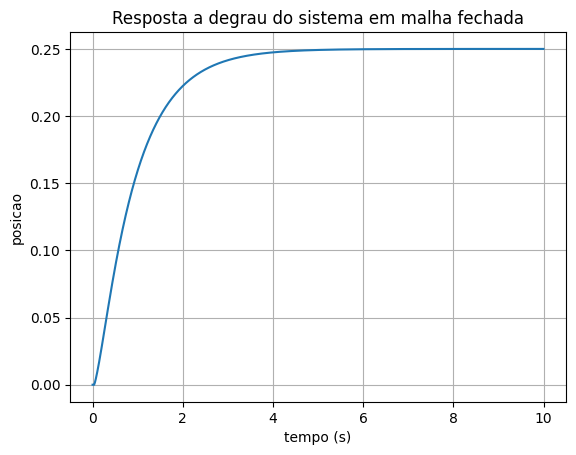

b-) Anote na tabela abaixo os valores obtidos para o tempo de subida $t_r$, tempo de acomodação
$t_s$, Máximo sobresinal $M_p$ da variável $r(t)$ e $\max \alpha(t)$ (Valor máximo da saída rotação da viga 
$\alpha(t)$)

|$$t_r$$|$$t_s$$|$$M_p$$|$$\max \alpha(t)$$|
|:-|:-|:-|:-|
|1.90|3.44|0|22.75|    

c-) O controlador projetado continua satisfazendo os requisitos de projeto?

**Não, o controlador quando testado com um degrau unitário em malha fechada apresenta um tempo de acomodação maior que 3 segundos, descumprindo o requisito projetado.**  

d-) Repita as simulações para um set-point de $0.1m$ e $0.5m$, como o sistema se comporta nesses caso? Anote na tabela abaixo os valores obtidos para o tempo de subida $t_r$, tempo de acomodação $t_s$, Máximo sobresinal $M_p$ da variável $r(t)$ e $\max \alpha(t)$ 

**Se comporta semelhante ao sistema anterior, com tempo de subida e sobressinal semelhantes, porém descumprindo o requisito de tempo de estabilização.**  

|set-point|$$t_r$$|$$t_s$$|$$M_p$$|$$\max \alpha(t)$$|
|:-|:-|:-|:-|:-|
|0.1m|1.83|3.29|0|9.10|  
|0.5m|1.9|3.48|0|45.49|

e-) Os valores máximos de rotação da viga $\max \alpha(t)$ fazem sentido fisicamente?

**Fisicamente os valores não fazem sentido, variando entre 521º e 2578º.**  

f-) Continue com o set-point de $0.25m$, mas nesse caso, ative a saturaçãoo da entrada de forma que $\max \alpha(t) < 0.5$ (basta ajustar a flag use_saturation=True no script). Anote na tabela abaixo os valores obtidos para o tempo de subida $t_r$, tempo de acomodação
$t_s$, Máximo sobresinal $M_p$ da variável $r(t)$ e $\max \alpha(t)$ 

**[substituir os valores de x na tabela]**

|$$t_r$$|$$t_s$$|$$M_p$$|$$\max \alpha(t)$$|
|:-|:-|:-|:-|
|1.89|3.40|0|0.5|    

g-) Como foi a variação do comportamento do sistema controlado com a inclusão da restrição de limitação da rotação da viga?

**O sistema segue respeitando o sobressinal e o tempo de subida. Não tivemos variação no tempo de acomodação, que continuou acima do requisito de projeto, porém o máximo de rotação da viga foi bem mais baixo, sendo o valor de 28.64º, devido à limitação imposta, o que faz sentido fisicamente.** 

In [10]:
class FilteredDerivative:
    def __init__(self, tau, dt):
        """
        tau: Time constant of the low-pass filter
        dt:  Sampling interval
        """
        self.tau = tau
        self.dt = dt
        self.prev_input = 0.0
        self.prev_derivative = 0.0

    def update(self, current_input):
        # Raw derivative (finite difference)
        raw_derivative = (current_input - self.prev_input) / self.dt
        
        # Filter coefficient
        alpha = self.tau / (self.tau + self.dt)

        # Apply low-pass filter
        filtered_derivative = alpha * self.prev_derivative + (1 - alpha) * raw_derivative

        # Save state
        self.prev_input = current_input
        self.prev_derivative = filtered_derivative

        return filtered_derivative
    
class PDControllerWithFilter:
    def __init__(self, kp, td, N, dt):
        """
        Parameters:
        kp: Proportional gain
        kd: Derivative gain
        tau: Derivative low-pass filter time constant
        dt: Sampling time (time step)
        """
        self.kp = kp
        self.kd = kp*td
        self.tau = td/N
        self.dt = dt
        self.filtered_derivative = FilteredDerivative(tau=self.tau, dt=self.dt)

    def update(self, setpoint, measurement):
        """
        Calculate control output.
        """
        error = setpoint - measurement
        # Apply the filtered derivative
        derivative = self.filtered_derivative.update(error)

        # PD Control Output
        output = self.kp * error + self.kd * derivative

        return output

-------------
CARACTERISTICAS DA RESPOSTA TRANSITORIA DO SISTEMA
tempo de subida tr =  1.89 seg
tempo de acomodacao ts =  3.40 seg
maximo sobresinal Mp =  0.0
valor de pico rmax =  0.25
instante de pico tp =  10.00 seg
valor de regime estacionario rss =  0.25


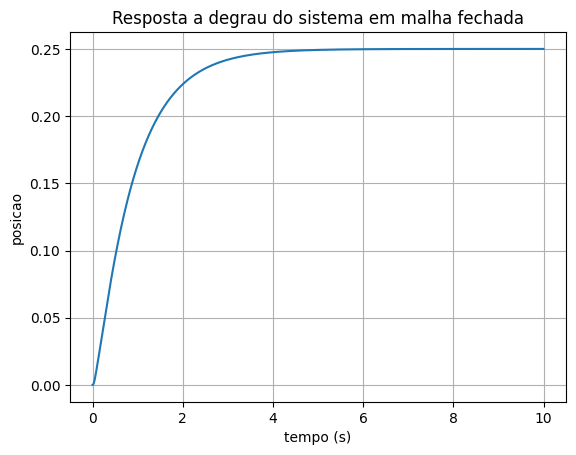

-------------
CARACTERISTICAS DO ESFORCO DE CONTROLE
valor de pico max_alpha =  0.50


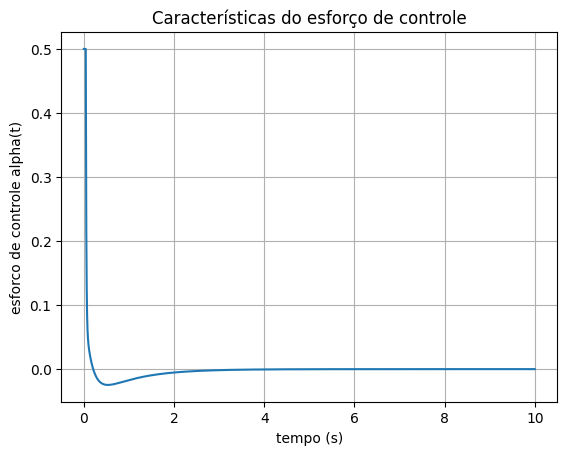

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import control.matlab as co
#
# Controle de Posicao Angular com controlador PID
#
# Definicao dos valores dos parametros do sistema

# Parametros da planta
m = 0.111
R = 0.015
g = -9.8
L = 1.0
d = 0.03
J = 9.99e-6

# Parametros da simulacao no tempo
dt = 0.001       # passo de tempo (s)
T = 10          # tempo total de simulacao (s)

# Valores iniciais
r = 0         # initial position (m)
r_dot = 0.0     # initial velocity (m/s)

# Parametros de controle
use_saturation = True
ulimit = 0.5 # saturacao do controlador
set_point = 0.25
Kp = 33
Td = 1
N = 100

pd_controller = PDControllerWithFilter(kp = Kp, td = Td, N=N, dt=dt)

# vetores para armazenar os dados
time_vect = []
r_vect = []
alpha_vect = []

# Simulaticao
for i in range(int(T / dt)):
    time = i * dt

    # Controle
    theta = pd_controller.update(set_point, r)  # update theta using PD controller
    alpha = theta*(d/L)
    if use_saturation:
        alpha = max(-ulimit, min(ulimit, alpha))

    # Dinamica do Sistema
    r_ddot = -m*g/(J/R**2+m)*np.sin(alpha) 

    # Integracao
    r_dot += r_ddot * dt
    r += r_dot * dt

    # Armazenar os dados
    time_vect.append(time)
    r_vect.append(r)
    alpha_vect.append(alpha)

# Calcula as caracteristicas da resposta transitoria
#  stepinfo(sysdata=r_vect, T=time_vect, SettlingTimeThreshold=0.02, RiseTimeLimits=(0.1,0.9))
#  S: a dictionary containing:
#        RiseTime: Time from 10% to 90% of the steady-state value.
#        SettlingTime: Time to enter inside a default error of 2%
#        SettlingMin: Minimum value after RiseTime
#        SettlingMax: Maximum value after RiseTime
#        Overshoot: Percentage of the Peak relative to steady value
#        Undershoot: Percentage of undershoot
#        Peak: Absolute peak value
#        PeakTime: time of the Peak
#        SteadyStateValue: Steady-state value
S=co.stepinfo(sysdata=r_vect, T=time_vect)
print('-------------')
print('CARACTERISTICAS DA RESPOSTA TRANSITORIA DO SISTEMA')
print('tempo de subida tr = ','%.2f' % S['RiseTime'],'seg')
print('tempo de acomodacao ts = ','%.2f' % S['SettlingTime'],'seg')
print('maximo sobresinal Mp = ',S['Overshoot'])
print('valor de pico rmax = ','%.2f' % S['Peak'])
print('instante de pico tp = ','%.2f' % S['PeakTime'],'seg')
print('valor de regime estacionario rss = ','%.2f' % S['SteadyStateValue'])
# Grafico da resposta a degrau unitario
plt.figure(3)
plt.plot(time_vect, r_vect)
plt.xlabel('tempo (s)')
plt.ylabel('posicao')
plt.title('Resposta a degrau do sistema em malha fechada')
plt.grid()
plt.show()
#
# Esforco de controle
#
# Caracteristicas da resposta transitória
SE=co.stepinfo(sysdata=alpha_vect, T=time_vect)
# Valor de pico
print('-------------')
print('CARACTERISTICAS DO ESFORCO DE CONTROLE')
print('valor de pico max_alpha = ','%.2f' % SE['Peak'])
# Grafico da resposta a degrau unitario
plt.figure(4)
plt.plot(time_vect, alpha_vect)
plt.title('Características do esforço de controle')
plt.xlabel('tempo (s)')
plt.ylabel('esforco de controle alpha(t)')
plt.grid()
plt.show()

## 6.2- Controlador PD para o ajuste de posição: Aplicação ao sistema completo

Utilizando os mesmo parâmetros do controle PD projetado anteriormente (inicialmente sem saturação, use_saturation=False), vamos simular o comportamento do sistema.

a-) Para um set-point de $0.25m$ (em relação à ponta esquerda da viga), o sistema com o controlador PD projetado é estável? Esboce abaixo a resposta transitória para uma entrada do tipo degrau unitário:

**Sim, o sistema projetado é estável, como visto no gráfico abaixo.**   

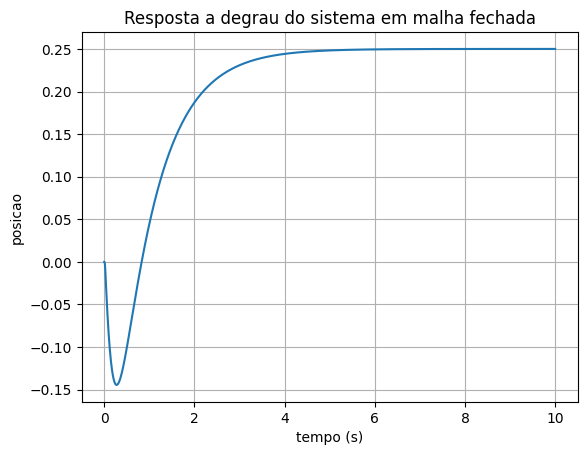

b-) Anote na tabela abaixo os valores obtidos para o tempo de subida $t_r$, tempo de acomodação
$t_s$, Máximo sobresinal $M_p$ da variável $r(t)$ e $\max \alpha(t)$ (Valor máximo da saída rotação da viga 
$\alpha(t)$)

|$$t_r$$|$$t_s$$|$$M_p$$|$$\max \alpha(t)$$|
|:-|:-|:-|:-|
|1.85|4.13|0|22.75|    

c-) O controlador projetado continua satisfazendo os requisitos de projeto?

**Não, pois o tempo de acomodação continua acima dos 3 segundos do requisito de projeto.**  

d-) Repita as simulações para um set-point de $0.1m$ e $0.5m$, como o sistema se comporta nesses caso? Anote na tabela abaixo os valores obtidos para o tempo de subida $t_r$, tempo de acomodação $t_s$, Máximo sobresinal $M_p$ da variável $r(t)$ e $\max \alpha(t)$ 

**O sistema se comporta de forma semelhante para o setpoint de 0.1, porém não funciona para o setpoint de 0.5, onde a resposta a degrau explode com o valor máximo indo para infinito.**  

|set-point|$$t_r$$|$$t_s$$|$$M_p$$|$$\max \alpha(t)$$|
|:-|:-|:-|:-|:-|
|0.1m|1.78|3.22|0|9.10|  
|0.5m|nan|nan|nan|inf|

e-) Continue com o set-point de $0.5m$, mas nesse caso, ative a saturaçãoo da entrada de forma que $\max \alpha(t) < 0.5$ (basta ajustar a flag use_saturation=True no script). Anote na tabela abaixo os valores obtidos para o tempo de subida $t_r$, tempo de acomodação
$t_s$, Máximo sobresinal $M_p$ da variável $r(t)$ e $\max \alpha(t)$ 

**[substituir os valores de x na tabela]**

|$$t_r$$|$$t_s$$|$$M_p$$|$$\max \alpha(t)$$|
|:-|:-|:-|:-|
|1.90|3.45|0|0.5|    

f-) Como foi a variação do comportamento do sistema controlado com a inclusão da restrição de limitação da rotação da viga?

**Com a inclusão da restrição de limitação da rotação da viga, o sistema foi impedido de explodir para o infinito, logo seu valor foi estabilizado, funcionando similar ao sistema simulado no item 6.1.** 

In [26]:
class FilteredDerivative:
    def __init__(self, tau, dt):
        """
        tau: Time constant of the low-pass filter
        dt:  Sampling interval
        """
        self.tau = tau
        self.dt = dt
        self.prev_input = 0.0
        self.prev_derivative = 0.0

    def update(self, current_input):
        # Raw derivative (finite difference)
        raw_derivative = (current_input - self.prev_input) / self.dt
        
        # Filter coefficient
        alpha = self.tau / (self.tau + self.dt)

        # Apply low-pass filter
        filtered_derivative = alpha * self.prev_derivative + (1 - alpha) * raw_derivative

        # Save state
        self.prev_input = current_input
        self.prev_derivative = filtered_derivative

        return filtered_derivative
    
class PDControllerWithFilter:
    def __init__(self, kp, td, N, dt):
        """
        Parameters:
        kp: Proportional gain
        kd: Derivative gain
        tau: Derivative low-pass filter time constant
        dt: Sampling time (time step)
        """
        self.kp = kp
        self.kd = kp*td
        self.tau = td/N
        self.dt = dt
        self.filtered_derivative = FilteredDerivative(tau=self.tau, dt=self.dt)

    def update(self, setpoint, measurement):
        """
        Calculate control output.
        """
        error = setpoint - measurement
        # Apply the filtered derivative
        derivative = self.filtered_derivative.update(error)

        # PD Control Output
        output = self.kp * error + self.kd * derivative

        return output

-------------
CARACTERISTICAS DA RESPOSTA TRANSITORIA DO SISTEMA
tempo de subida tr =  1.90 seg
tempo de acomodacao ts =  3.45 seg
maximo sobresinal Mp =  0.0
valor de pico rmax =  0.50
instante de pico tp =  10.00 seg
valor de regime estacionario rss =  0.50


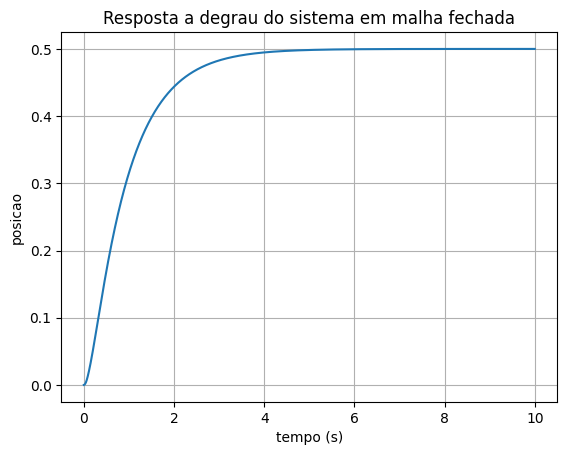

-------------
CARACTERISTICAS DO ESFORCO DE CONTROLE
valor de pico max_alpha =  0.50


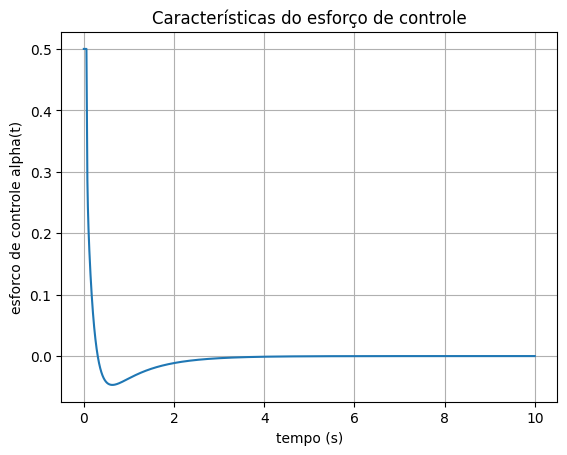

In [28]:
import numpy as np
import matplotlib.pyplot as plt
import control.matlab as co
#
# Controle de Posicao Angular com controlador PID
#
# Definicao dos valores dos parametros do sistema

# Parametros da planta
m = 0.111
R = 0.015
g = -9.8
L = 1.0
d = 0.03
J = 9.99e-6

# Parametros da simulacao no tempo
dt = 0.001       # passo de tempo (s)
T = 10          # tempo total de simulacao (s)
tau = 0.001     # constante de tempo do filtro da derivada (s)
filtered_derivative = FilteredDerivative(tau=tau, dt=dt)

# Valores iniciais
r = 0         # posicao inicial da bolda
r_dot = 0.0     # velocidade inicial da bola

# Parametros de controle
use_saturation = True
ulimit = 0.5 # saturacao do controlador
set_point = 0.5
Kp = 33
Td = 1
N = 100

pd_controller = PDControllerWithFilter(kp = Kp, td = Td, N=N, dt=dt)

# vetores para armazenar os dados
time_vect = []
r_vect = []
alpha_vect = []

# Simulaticao
for i in range(int(T / dt)):
    time = i * dt

    # Controle
    theta = pd_controller.update(set_point, r)  # update theta using PD controller
    alpha = theta*(d/L)
    if use_saturation:
        alpha = max(-ulimit, min(ulimit, alpha))

    # Dinamica do Sistema
    dalpha = filtered_derivative.update(alpha)
    r_ddot = -m*g/(J/R**2+m)*np.sin(alpha) + m*r*dalpha**2

    # Integracao
    r_dot += r_ddot * dt
    r += r_dot * dt

    # Armazenar os dados
    time_vect.append(time)
    r_vect.append(r)
    alpha_vect.append(alpha)

# Calcula as caracteristicas da resposta transitoria
#  stepinfo(sysdata=r_vect, T=time_vect, SettlingTimeThreshold=0.02, RiseTimeLimits=(0.1,0.9))
#  S: a dictionary containing:
#        RiseTime: Time from 10% to 90% of the steady-state value.
#        SettlingTime: Time to enter inside a default error of 2%
#        SettlingMin: Minimum value after RiseTime
#        SettlingMax: Maximum value after RiseTime
#        Overshoot: Percentage of the Peak relative to steady value
#        Undershoot: Percentage of undershoot
#        Peak: Absolute peak value
#        PeakTime: time of the Peak
#        SteadyStateValue: Steady-state value
S=co.stepinfo(sysdata=r_vect, T=time_vect)
print('-------------')
print('CARACTERISTICAS DA RESPOSTA TRANSITORIA DO SISTEMA')
print('tempo de subida tr = ','%.2f' % S['RiseTime'],'seg')
print('tempo de acomodacao ts = ','%.2f' % S['SettlingTime'],'seg')
print('maximo sobresinal Mp = ',S['Overshoot'])
print('valor de pico rmax = ','%.2f' % S['Peak'])
print('instante de pico tp = ','%.2f' % S['PeakTime'],'seg')
print('valor de regime estacionario rss = ','%.2f' % S['SteadyStateValue'])
# Grafico da resposta a degrau unitario
plt.figure(3)
plt.plot(time_vect, r_vect)
plt.xlabel('tempo (s)')
plt.ylabel('posicao')
plt.title('Resposta a degrau do sistema em malha fechada')
plt.grid()
plt.show()
#
# Esforco de controle
#
# Caracteristicas da resposta transitória
SE=co.stepinfo(sysdata=alpha_vect, T=time_vect)
# Valor de pico
print('-------------')
print('CARACTERISTICAS DO ESFORCO DE CONTROLE')
print('valor de pico max_alpha = ','%.2f' % SE['Peak'])
# Grafico da resposta a degrau unitario
plt.figure(4)
plt.plot(time_vect, alpha_vect)
plt.title('Características do esforço de controle')
plt.xlabel('tempo (s)')
plt.ylabel('esforco de controle alpha(t)')
plt.grid()
plt.show()

# Discussões

**[Resposta]**

# Conclusões

**[Resposta]**